In [31]:
cd ..

/share/gpu0/mars/src_aiai


In [3]:
import os


In [4]:
os.environ['CUDA_VISIBLE_DEVICES']

'-1'

In [4]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

In [5]:
from src.util import gpu_setup
gpu_setup()

1 actual GPUs, 0 in use.


In [6]:
import os
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [7]:
from astropy.io import fits

In [5]:
snr = lambda x,y: 20 * np.log( np.linalg.norm(x) / np.linalg.norm(x-y))
log_snr = lambda x, y: snr(np.log(x), np.log(y))

def compare_multiple(images, ncols=None, nrows=None, titles=None, same_scale=False, colorbar=False, cmap='viridis', save_base="./plots/example", cbar_anchor=(1.2, 0), rot=0, vmin=None, vmax=None, ylabel="", log=False, PSNR=True):
    """[summary]
    TODO add colorbars
    Args:
        images ([type]): [description]
        ncols ([type], optional): [description]. Defaults to None.
        nrows ([type], optional): [description]. Defaults to None.
        titles ([type], optional): [description]. Defaults to None.
        same_scale (bool, optional): [description]. Defaults to False.
    """

    if not nrows:
        nrows = 1
    if not ncols:
        ncols = 1
    if ncols*nrows < len(images):
        ncols = len(images)
        nrows = 1
    if not titles:
        titles = [""]*len(images)
    
    images = [np.rot90(i, rot) for i in images]
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, 
        figsize=(ncols*6, nrows*6 +1), squeeze=False)

    if log:
        psnr_images = images
        images = np.log10(np.array(images) + 1e-3)
    else:
        psnr_images = images
    
    a = ax[0,0].imshow(images[0])    
    ax[0,0].set_title(titles[0])
    ax[0,0].set_ylabel(ylabel)
    

    
    if vmin is None:
        vmin, vmax = a.get_clim()
    for i in range(0, nrows):
        for j in range(ncols):
            if i +j*nrows >= len(images):
                break
            if same_scale:
                im = ax[i,j].imshow(images[j + i*ncols], 
                    vmin=vmin, vmax=vmax, cmap=cmap)
            else:
                im = ax[i,j].imshow(images[j + i*ncols], cmap=cmap)
            if j % ncols != 0:
                if titles[j + i*ncols]:
                    if PSNR:
                        if not log:
                            ax[i,j].set_title(titles[j + i*ncols]  + f"\n(SNR: {snr(images[i*ncols], images[j + i*ncols]):.2f}dB)" ) 
                        else:
                            ax[i,j].set_title(titles[j + i*ncols]  + f"\n(logSNR: {log_snr(psnr_images[i*ncols], psnr_images[j + i*ncols]):.2f}dB)" ) 
#                         ax[i,j].set_title(titles[j + i*ncols]  + f"\n(SNSNR: {peak_signal_noise_ratio(psnr_images[i*ncols], psnr_images[j + i*ncols], data_range=psnr_images[i*ncols].max()- psnr_images[i*ncols].min()):.2f}dB)" ) 
                    else: 
                        ax[i,j].set_title(titles[j + i*ncols])
                else:
                    if PSNR:
                        if not log:
                            ax[i,j].set_title(f"(SNR: {snr(images[i*ncols], images[j + i*ncols]):.2f}dB)" ) 
                        else:
                            ax[i,j].set_title(f"(logSNR: {log_snr(images[i*ncols], images[j + i*ncols]):.2f}dB)" ) 
                    
                        
            else:
                if titles[j + i*ncols]:
                    ax[i,j].set_title(titles[j + i*ncols] +"\n")
                else:
                    ax[i,j].set_title(titles[j + i*ncols])
                    
            ax[i,j].set_xticks([])
            ax[i,j].set_yticks([])
    if colorbar:
#         plt.colorbar(im, ax=ax, anchor=cbar_anchor, shrink=.8)
        plt.colorbar(im, ax=ax,anchor=cbar_anchor, fraction=0.046, pad=0.04, shrink=.87)
    plt.subplots_adjust(wspace=.025)

# radio image

In [6]:
from skimage.transform import rescale, resize, downscale_local_mean


In [4]:
from astropy.io import fits

In [5]:
a = fits.getdata("./notebooks/30dor_256.fits")
b = fits.getdata("./notebooks/M31_256.fits")
c = fits.getdata("./notebooks/cluster.fits")

INSTRUME                                                                         [astropy.io.fits.card]


In [9]:
np.save('30Dor_360.npy', resize(a, (360,360)))

In [9]:
b.min(), c.min()

(-2.215284e-09, -8.490161e-08)

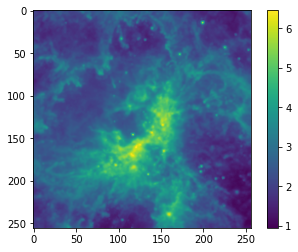

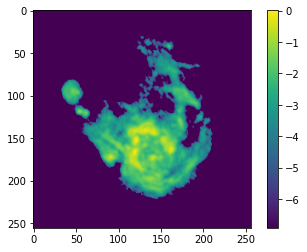

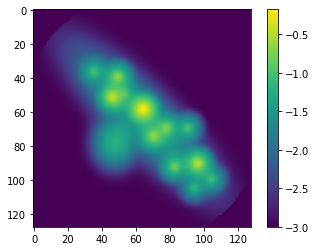

In [10]:
plt.imshow(np.log(a))
plt.colorbar()
plt.show()
plt.imshow(np.log(b[0]+1e-3))
plt.colorbar()
plt.show()
plt.imshow(np.log10(c+1e-3)[0,0])
plt.colorbar()
plt.show()

In [11]:
im1 = np.mean(mpimg.imread('./notebooks/3c353.jpg'), axis=2)
im1 /= im1.max()
log_im1 = np.log(im1 + 1e-9)
# im2 = mpimg.imread('./notebooks/3c353.jpg')

In [12]:
im1.shape

(475, 800)

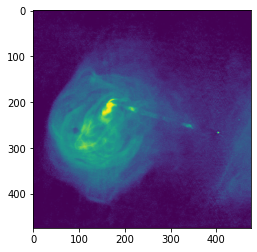

In [13]:
plt.imshow(im1[:475,:475])

In [14]:
im2 = resize(np.pad(im1, ((150, 175), (0,0)), mode="reflect"), (256,256), mode='constant')
im2 /= im2.max()

In [15]:
im2 = resize(im1[:475,:475],  (256,256))
im2 /= im2.max()

In [16]:
im2 = (a-a.min()) / (a.max()-a.min())

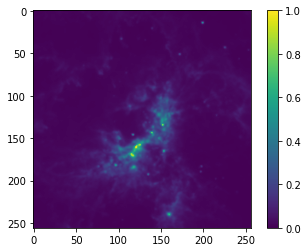

In [17]:
plt.imshow(im2)
plt.colorbar()
plt.show()

# Radio vis

In [7]:
h = fits.getheader("./notebooks/my.uvfits")
h

SIMPLE  =                    T /Standard FITS format                            
BITPIX  =                  -32 /Floating point values                           
NAXIS   =                    7                                                  
NAXIS1  =                    0 /Random groups, NOT image                        
NAXIS2  =                    3                                                  
NAXIS3  =                    2                                                  
NAXIS4  =                    1                                                  
NAXIS5  =                    1                                                  
NAXIS6  =                    1                                                  
NAXIS7  =                    1                                                  
EXTEND  =                    T /Tables may follow                               
BLOCKED =                    T /File may be blocked                             
GROUPS  =                   

In [21]:
from casatools import ms

In [24]:
ms.open('/share/gpu0/mars/im_0/im_0.ms')

AttributeError: 'str' object has no attribute '_swigobj'

In [ ]:
ls /share/gpu0/mars/im_0/im_0.ms/

In [2]:
from casatasks import exportuvfits

In [15]:
exportuvfits(vis="/share/gpu0/mars/im_1/im_0.ms", fitsfile="test.uvfits", overwrite=True)


In [27]:
fits.getheader("./my.uvfits")


SIMPLE  =                    T /Standard FITS format                            
BITPIX  =                  -32 /Floating point values                           
NAXIS   =                    7                                                  
NAXIS1  =                    0 /Random groups, NOT image                        
NAXIS2  =                    3                                                  
NAXIS3  =                    2                                                  
NAXIS4  =                    1                                                  
NAXIS5  =                    1                                                  
NAXIS6  =                    1                                                  
NAXIS7  =                    1                                                  
EXTEND  =                    T /Tables may follow                               
BLOCKED =                    T /File may be blocked                             
GROUPS  =                   

In [32]:
d =  fits.getdata("./notebooks/my.uvfits")
# d =  fits.getdata("./test.uvfits")

u, v, w = d['UU'], d['VV'], d['WW']
uv_radio = np.vstack((d['UU'], d['VV'])).T
uv_radio = uv_radio #/np.linalg.norm(uv_radio, axis=1).max()*np.pi
uv_radio = uv_radio * 7e8 /1e3 # divide by rest frequency, 1e3 -> k \lambda



In [37]:
def plot_uv(uv, fontsize=18):
    plt.figure(figsize=(6,6))
    plt.scatter(uv[:,0], uv[:,1], s=.1 )
#     plt.xticks(
#         np.linspace(-np.pi, np.pi, 5), 
#         [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"],
#         fontsize=fontsize
#     )    
#     plt.yticks(
#         np.linspace(-np.pi, np.pi, 5), 
#         [r"$-\pi$", r"$-\frac{\pi}{2}$", r"$0$", r"$\frac{\pi}{2}$", r"$\pi$"],
#         fontsize=fontsize
#     )    
    plt.xlabel(r'$u$ ($k\lambda$)')
    plt.ylabel(r'$v$ ($k\lambda$)')


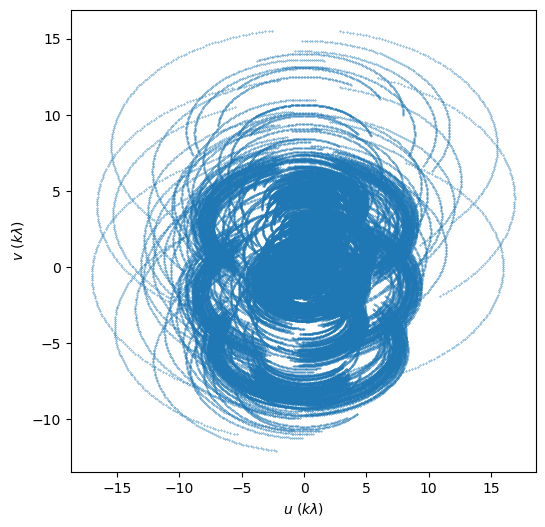

In [38]:
plot_uv(uv_radio)
plt.savefig("./plots_ri/meerkat_coverage.png", dpi=1000)
# plt.savefig("./plots_ri/meerkat_coverage.pdf")

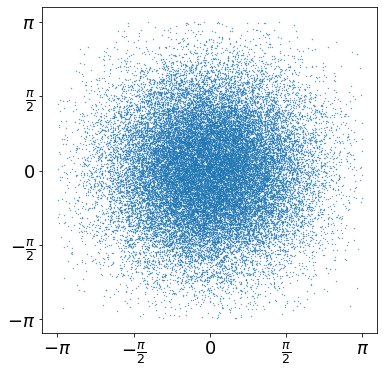

In [24]:
uv_test = np.load("./data/intermediate/TNG/NUFFT_Random_var/uv_original.npy")
plot_uv(uv_test)
plt.savefig("./plots_ri/gauss_coverage.pdf")

In [25]:
(len(uv_test)/len(uv_radio))**-1

7.38303781243324

In [26]:
len(uv_test), len(uv_radio)

(32767, 241920)

# Radio operator

In [27]:
from src.operators.NUFFT2D_TF import NUFFT2D_TF

In [28]:
data = "TNG"
operator = "NUFFT_Random_var"

In [29]:
Nd =(256,256)
Kd = (512, 512)
Jd = (6,6)
batch_size = 1

# m_op_radio = NUFFT2D_TF()
# m_op_radio.plan(uv_radio, Nd, Kd, Jd, batch_size)


m_op_test = NUFFT2D_TF()
m_op_test.plan(uv_test, Nd, Kd, Jd, batch_size)

100%|██████████| 32767/32767 [00:09<00:00, 3445.82it/s]


some values lie out of the interpolation array, these are not used, check baselines


In [30]:
# sampling density based weighting
def calc_w(uv):
    grid_cell = 2*np.pi /512 
    binned = (uv[:,:]+np.pi+.5*grid_cell) // grid_cell
    binned = [tuple(x) for x in binned]
    w_gridded = np.zeros(uv.shape[0])

    d = {}
    for i in tqdm.tqdm(binned):
        if i in d:
            d[i] += 1
        else:
            d[i] = 1

    for i in range(len(w_gridded)):
        w_gridded[i] = d[binned[i]]
    # w = 
    w = 1/w_gridded
    w /= w.max()
    return w

# w_radio = calc_w(uv_radio)
w_test = calc_w(uv_test)


100%|██████████| 32767/32767 [00:00<00:00, 1129458.42it/s]


# RI net

In [31]:
import tensorflow as tf
from src.networks.UNet_var import UNet_var
from src.networks.GUNet_var import GUNet_var

In [32]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio, mean_squared_error


In [33]:
operator = "NUFFT_Random_var"
data = "TNG"
ISNR = 30
project_folder = os.environ["HOME"] + "/src_aiai/"
data_folder = project_folder + f"data/intermediate/{data}/{operator}/"

# uv_test = np.load(data_folder + "/uv_original.npy")


In [34]:
# y_radio = m_op_radio.dir_op(im2[np.newaxis, :])
y_test = m_op_test.dir_op(im2[np.newaxis, :])




In [35]:
ISNR=30
y_test = m_op_test.dir_op(im2[np.newaxis, :])
data_shape = len(y_test)

sigma = np.sqrt(np.mean(np.abs(y_test)**2)) * 10**(-ISNR/20)
n = np.random.normal( 0, sigma, data_shape) + 1j * np.random.normal( 0, sigma, data_shape)
y_test = y_test + n/np.sqrt(2) # 

In [36]:
project_folder = os.environ["HOME"] + "/src_aiai/"

data_folder = project_folder + f"data/intermediate/{data}/{operator}/"
print(data_folder)

/home/mars/src_aiai/data/intermediate/TNG/NUFFT_Random_var/


## UNet

In [37]:
unet_test = UNet_var(
    Nd, 
    uv=uv_test,
    op=NUFFT2D_TF, 
    depth=4, 
    conv_layers=2,
    input_type="measurements", 
    measurement_weights=np.ones(len(uv_test)),
    batch_size=batch_size,
    residual=True
    )

100%|██████████| 32767/32767 [00:09<00:00, 3396.02it/s]


some values lie out of the interpolation array, these are not used, check baselines
KerasTensor(type_spec=TensorSpec(shape=(None, 32767), dtype=tf.complex64, name='input_1'), name='input_1', description="created by layer 'input_1'") KerasTensor(type_spec=TensorSpec(shape=(1, 256, 256), dtype=tf.float32, name=None), name='tf.__operators__.add/AddV2:0', description="created by layer 'tf.__operators__.add'")


In [38]:
network = "UNet_var"
postfix = "_known_new2"
checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
unet_test.load_weights(latest)

y_pred_known = unet_test.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [39]:
z_test =  np.ones_like(y_test.numpy())

In [40]:
import time

In [57]:
st = time.time_ns()
times = [st]
for i in range(10):
    unet_test.predict((y_test, z_test))
    times.append(time.time_ns())
    
times = np.ediff1d(times)
np.mean(times)/1e3, np.std(times)/1e3

(879355.8222, 315321.7584654133)

In [56]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [58]:
%%timeit -n 1 -r 10
a = unet_test.predict((y_test, z_test));

814 ms ± 270 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


In [64]:
a = tf.convert_to_tensor(y_test)
z = tf.convert_to_tensor(z_test)

In [65]:
%%timeit -n 1 -r 10
unet_test.predict((a, z));

742 ms ± 204 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


In [ ]:
76.4 ms ± 2.1 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


In [68]:
network = "UNet_var"
postfix = "_general_new2"
checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
unet_test.load_weights(latest)

y_pred_general = unet_test.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [69]:
network = "UNet_var"
postfix = "_general_known_new2"
checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
unet_test.load_weights(latest)

y_pred_general_known = unet_test.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [70]:
network = "UNet_var"
postfix = "_specific_new2"
checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
unet_test.load_weights(latest)

y_pred_specific = unet_test.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [71]:
network = "UNet_var"
postfix = "_specific_known_new2"
checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
unet_test.load_weights(latest)

y_pred_specific_known = unet_test.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [66]:
%%timeit -r 10 -n 1
x_dirty = m_op_test.adj_op(y_test)

173 ms ± 34.9 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


In [73]:
x_dirty = m_op_test.adj_op(y_test).numpy().real[0]

In [74]:
res =  a.min() + (a.max()-a.min())*np.array([im2, x_dirty, y_pred_known[0], y_pred_specific[0], y_pred_specific_known[0], y_pred_general[0], y_pred_general_known[0]])

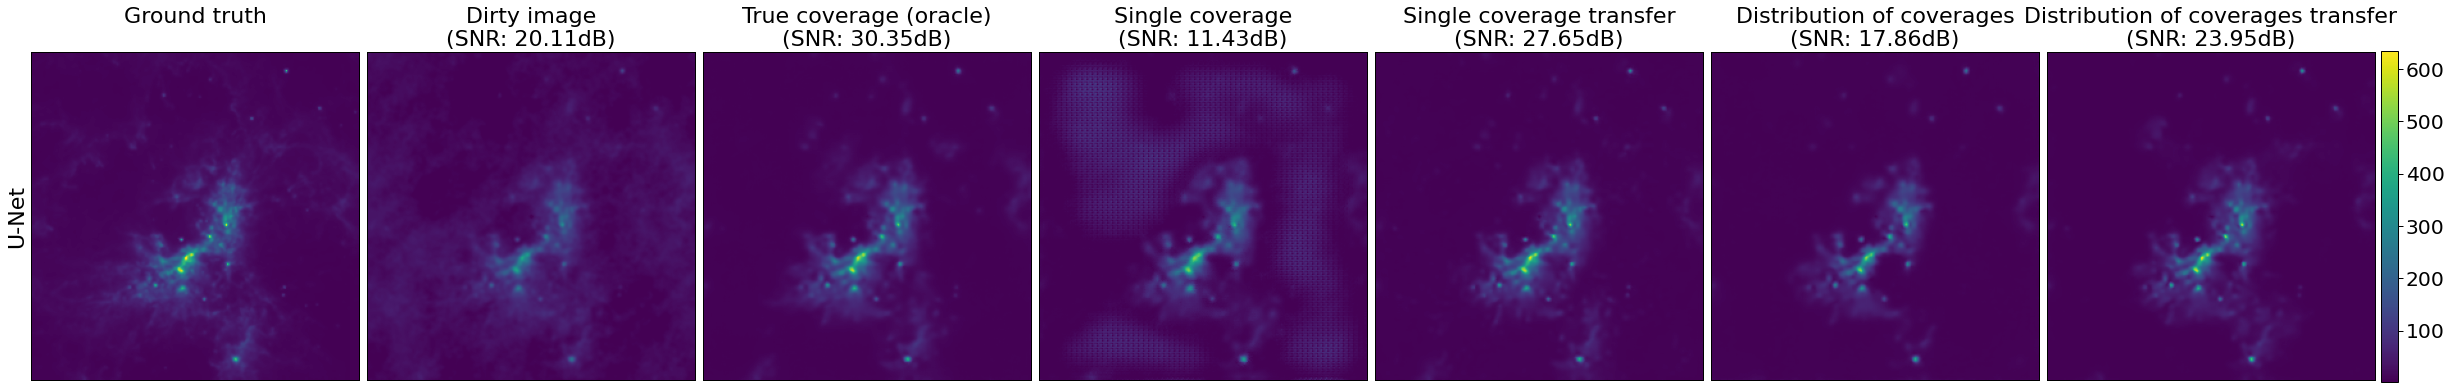

In [77]:
import seaborn as sns
sns.set_context('paper', font_scale=2.3)

compare_multiple(res, titles=["Ground truth", "Dirty image", "True coverage (oracle)", "Single coverage", "Single coverage transfer", "Distribution of coverages", "Distribution of coverages transfer"], same_scale=True, ylabel="U-Net", cbar_anchor=(1.25,.5), colorbar=True)
plt.savefig("./plots_ri/examples_radio_UNet_30Dor.pdf")

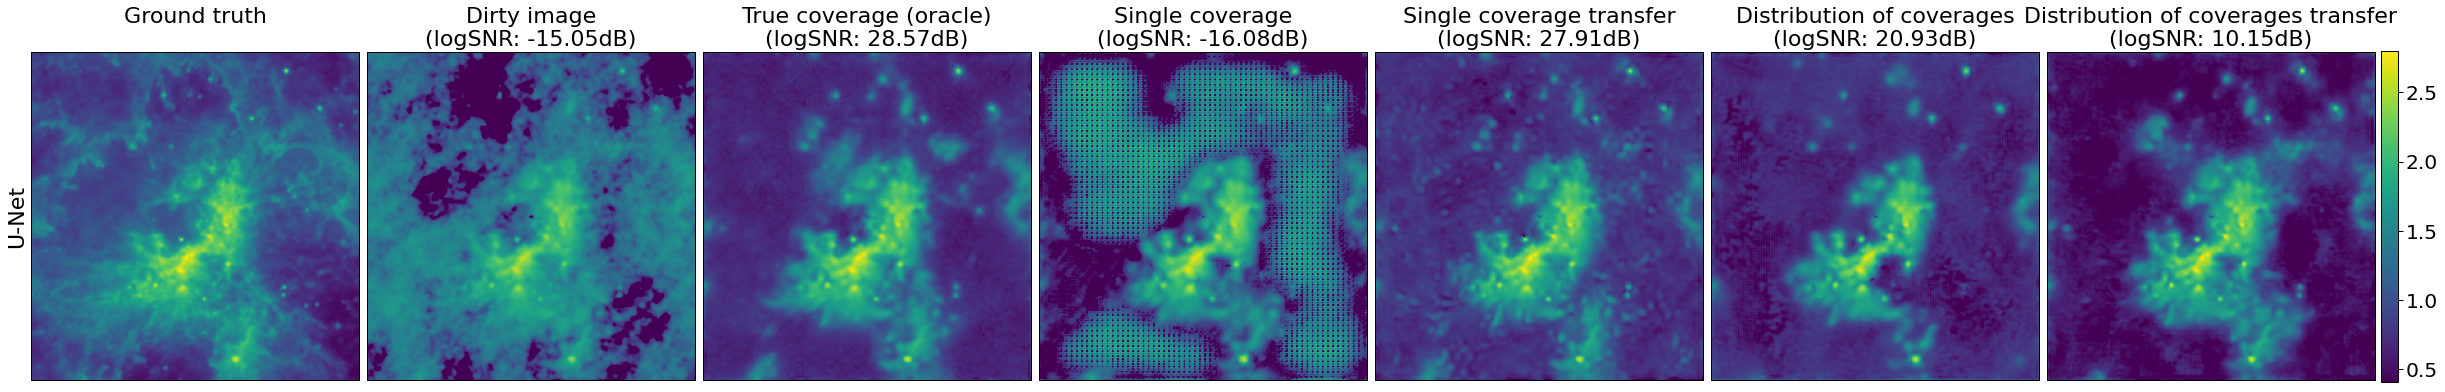

In [78]:
res[res<=0] = 1e-9
compare_multiple(res, titles=["Ground truth", "Dirty image", "True coverage (oracle)", "Single coverage", "Single coverage transfer", "Distribution of coverages", "Distribution of coverages transfer"], same_scale=True, colorbar=True, log=True, ylabel="U-Net", cbar_anchor=(1.25,.5))
plt.savefig("./plots_ri/examples_radio_UNet_log_30Dor.pdf")

In [58]:
del unet_test

## GUNET

In [37]:
gunet = GUNet_var(
    Nd, 
    uv=uv_test,
    op=NUFFT2D_TF, 
    depth=4, 
    conv_layers=2,
    input_type="measurements", 
    measurement_weights=np.ones(len(uv_test)),
    batch_size=batch_size,
    residual=True
    )

100%|██████████| 32767/32767 [00:05<00:00, 5730.38it/s]


some values lie out of the interpolation array, these are not used, check baselines


100%|██████████| 28602/28602 [00:04<00:00, 5888.21it/s]


some values lie out of the interpolation array, these are not used, check baselines


100%|██████████| 19773/19773 [00:03<00:00, 5769.53it/s]


some values lie out of the interpolation array, these are not used, check baselines


100%|██████████| 13810/13810 [00:02<00:00, 5852.45it/s]


some values lie out of the interpolation array, these are not used, check baselines


100%|██████████| 10908/10908 [00:01<00:00, 5878.21it/s]


some values lie out of the interpolation array, these are not used, check baselines
KerasTensor(type_spec=TensorSpec(shape=(None, 32767), dtype=tf.complex64, name='input_1'), name='input_1', description="created by layer 'input_1'") KerasTensor(type_spec=TensorSpec(shape=(1, 256, 256), dtype=tf.float32, name=None), name='tf.__operators__.add/AddV2:0', description="created by layer 'tf.__operators__.add'")


In [79]:
network = "GUNet_var"
postfix = "_general_new"

data = "TNG"

checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
gunet.load_weights(latest)

data ="TNG"

y_pred_general = gunet.predict((y_test.numpy(), np.ones_like(y_test.numpy())))


In [80]:
z_test = np.ones_like(y_test.numpy())

In [81]:
%%timeit -r 10 -n 1
y_pred_general = gunet.predict((y_test, z_test))


128 ms ± 6.24 ms per loop (mean ± std. dev. of 10 runs, 1 loop each)


In [82]:
y_pred_general = gunet.predict((y_test, z_test))


In [83]:
network = "GUNet_var"
postfix = "_specific_new2"

data = "TNG"

checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
gunet.load_weights(latest)

data ="TNG"

y_pred_specific = gunet.predict((y_test.numpy(), np.ones_like(y_test.numpy())))


In [84]:
network = "GUNet_var"
postfix = "_known_new"

data = "TNG"

checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
gunet.load_weights(latest)

data ="TNG"

y_pred_known = gunet.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [85]:
network = "GUNet_var"
postfix = "_specific_known_new"

data = "TNG"

checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
gunet.load_weights(latest)

data ="TNG"

y_pred_specific_known = gunet.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [86]:
network = "GUNet_var"
postfix = "_general_known_new"

data = "TNG"

checkpoint_folder = project_folder+ f"models/{data}/{operator}/{network}_{ISNR}dB{postfix}"
latest = tf.train.latest_checkpoint(checkpoint_folder)
gunet.load_weights(latest)

data ="TNG"

y_pred_general_known = gunet.predict((y_test.numpy(), np.ones_like(y_test.numpy())))

In [92]:
# x_dirty = m_op_test.adj_op(y_test).numpy().real[0]
res =  a.min() + (a.max()-a.min())*np.array([im2, x_dirty, y_pred_known[0], y_pred_specific[0], y_pred_specific_known[0], y_pred_general[0], y_pred_general_known[0]])

In [93]:
res[res<=0] = 1e-9

In [94]:
y_pred_known[0].min(), y_pred_known[0].max(), im2.min(), im2.max()

(-0.035420638, 1.023943, 0.0, 1.0)

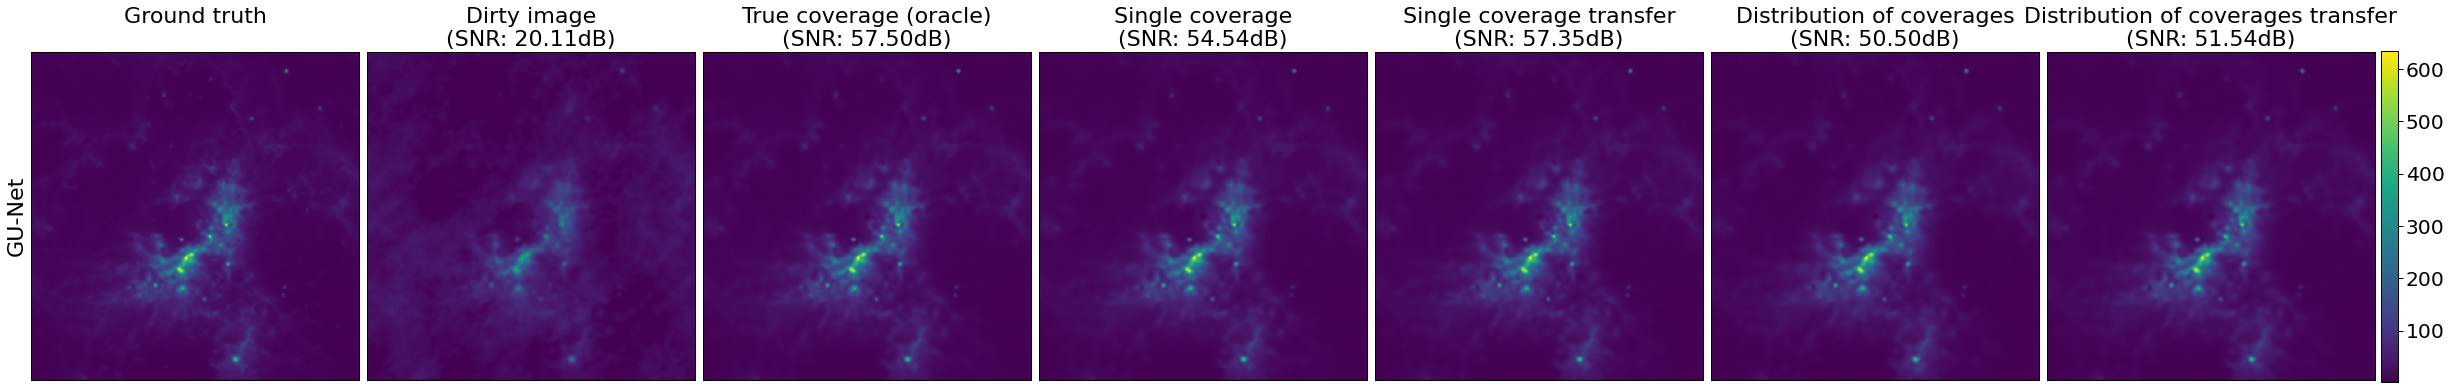

In [95]:
import seaborn as sns
sns.set_context('paper', font_scale=2.3)

compare_multiple(res, titles=["Ground truth", "Dirty image", "True coverage (oracle)", "Single coverage", "Single coverage transfer", "Distribution of coverages", "Distribution of coverages transfer"], same_scale=True, ylabel="GU-Net", cbar_anchor=(1.25,.5), colorbar=True)
plt.savefig("./plots_ri/examples_radio_GUNet_30Dor.pdf")

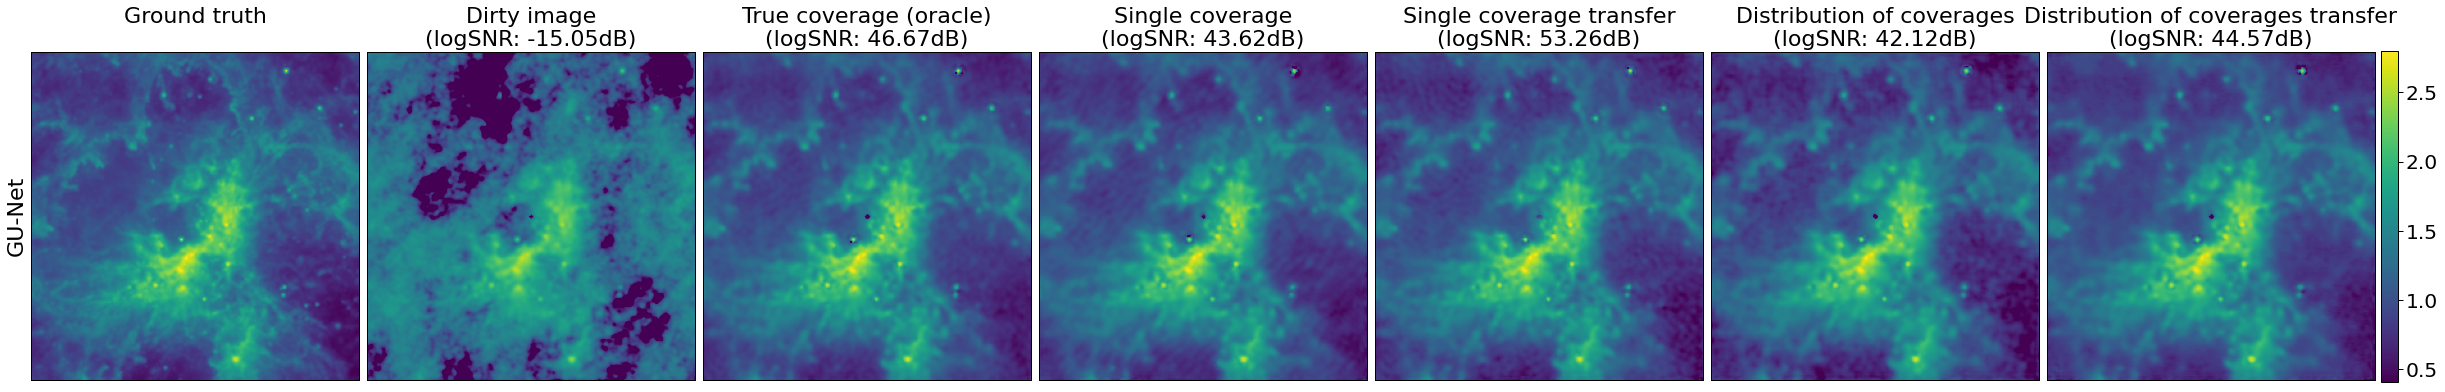

In [96]:
res[res<=0] = 1e-9
compare_multiple(res, titles=["Ground truth", "Dirty image", "True coverage (oracle)", "Single coverage", "Single coverage transfer", "Distribution of coverages", "Distribution of coverages transfer"], same_scale=True, colorbar=True, log=True, ylabel="GU-Net", cbar_anchor=(1.25,.5))
plt.savefig("./plots_ri/examples_radio_GUNet_log_30Dor.pdf")